<a href="https://colab.research.google.com/github/yuktiverma43/Data-Science-Projects/blob/main/git_hub_food_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/foodhub_order.csv')


In [ ]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
data.shape

(1898, 9)

#### Observations:
The dataframe has 1898 rows and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
1. The dataframe has not any missing value.
2. There are four columns of int type which are order_id, customer_id,food_preparation_time and delivery_time.
3. There are four columns of object or string type which are restaurant_name, cuisine_type, day_of_the_week and rating.
4. There is one column of float type which is cost_Of_the_order





### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
data.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:
There is no missing value in dataframe.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
data.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


#### Observations:
1. Columns order_id and customer_id are unique, the statistical summary of these columns are not giving any useful information.

2. The minimum time for food preparation is 20 minutes and maximum time is 35 minutes. Food preparation time is the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
Also, average time to prepare food is 27 minutes and 37 seconds.

3. The mean delivery time is 24 minutes and 16 seconds, 25% of orders for delivery takes 20 minutes and 50% of orders take 25 minutes while maximum time for delivery is 33 minutes.

4. The average cost of order is 16.50 dollars  and median is 14.14 dollars. The minimum cost of order is 4.47 dollars and maximum cost of order is 35.41 dollars


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
data[data['rating']=='Not given']

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,Not given,28,21
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,Not given,34,28
14,1478198,62667,Lucky's Famous Burgers,American,12.13,Weekday,Not given,23,30
...,...,...,...,...,...,...,...,...,...
1887,1476873,237616,Shake Shack,American,5.82,Weekend,Not given,26,30
1891,1476981,138586,Shake Shack,American,5.82,Weekend,Not given,22,28
1892,1477473,97838,Han Dynasty,Chinese,29.15,Weekend,Not given,29,21
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24


#### Observations:
Out of total 1898, 736 orders placed by customers are not rated by them.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

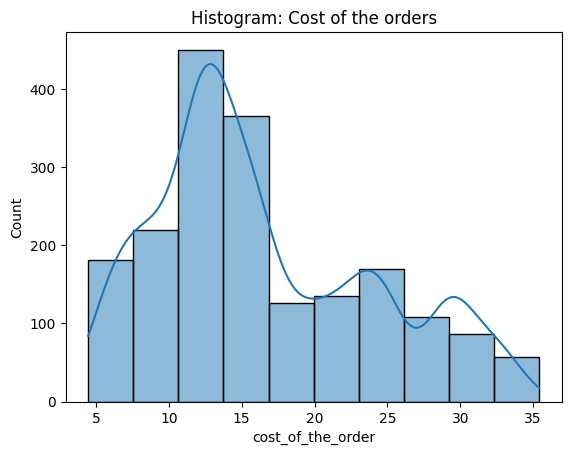

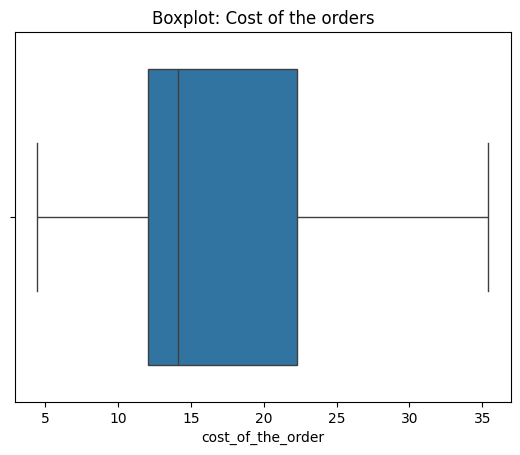

In [ ]:
# Write the code here
sns.histplot(data,x='cost_of_the_order',kde=True, bins=10)
plt.title('Histogram: Cost of the orders')
plt.show()
sns.boxplot(data,x='cost_of_the_order')
plt.title('Boxplot: Cost of the orders')
plt.show()

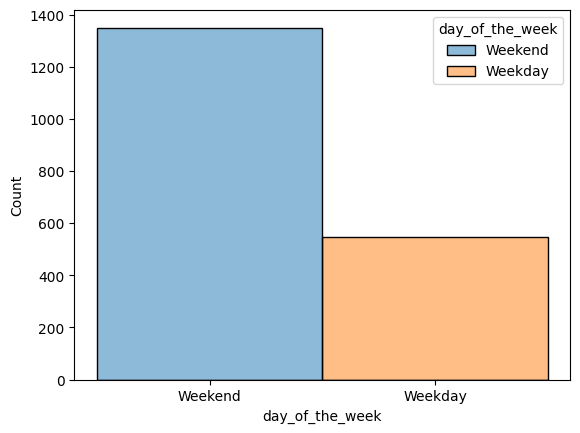

In [ ]:
sns.histplot(data,x='day_of_the_week',hue='day_of_the_week')
plt.show()

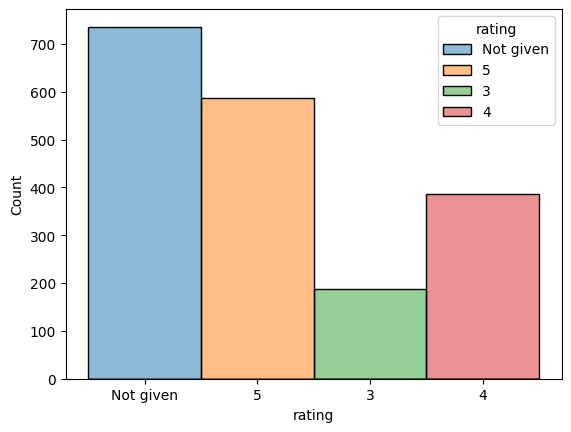

In [ ]:
sns.histplot(data,x='rating', hue='rating')
plt.show()


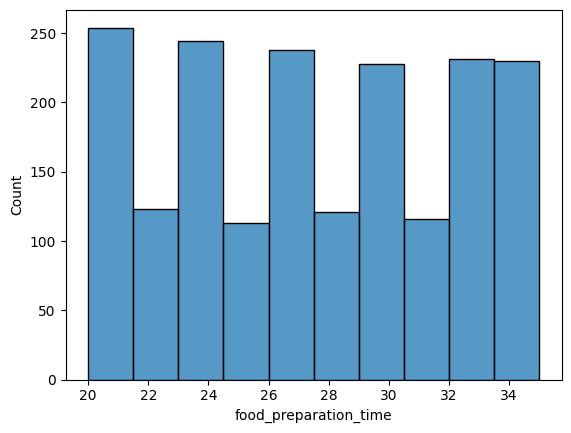

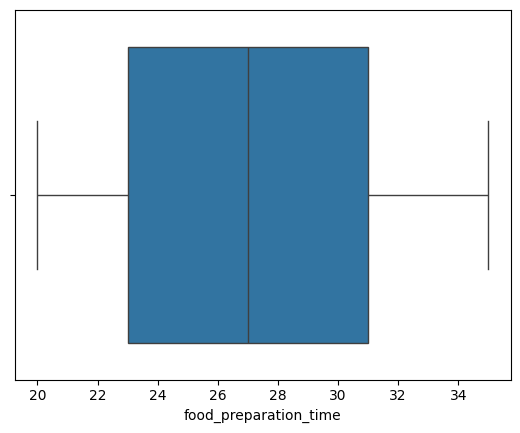

In [ ]:
sns.histplot(data,x='food_preparation_time',bins=10)
plt.show()
sns.boxplot(data,x='food_preparation_time')
plt.show()

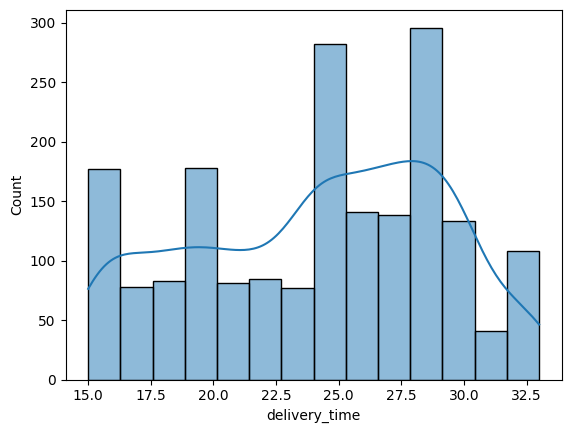

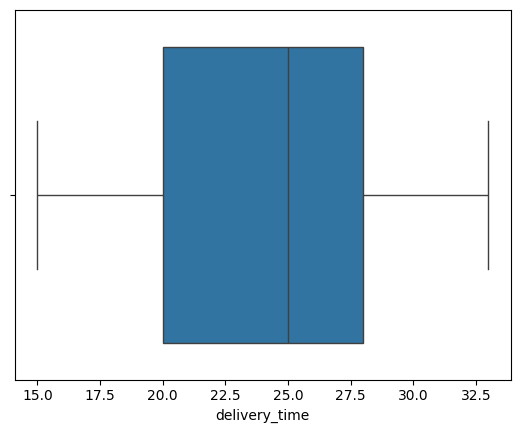

In [ ]:
sns.histplot(data,x='delivery_time',kde=True)
plt.show()
sns.boxplot(data,x='delivery_time')
plt.show()

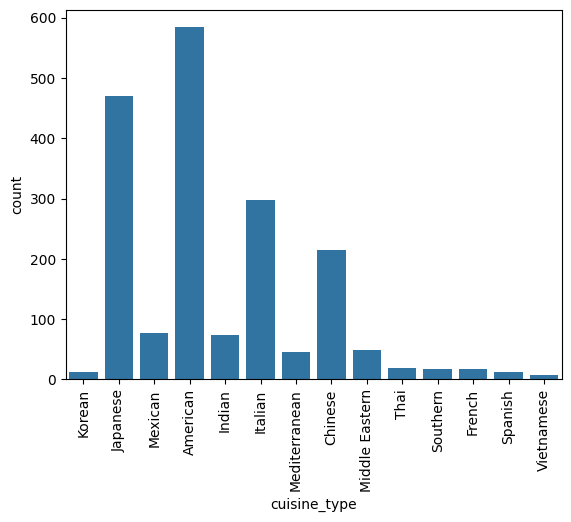

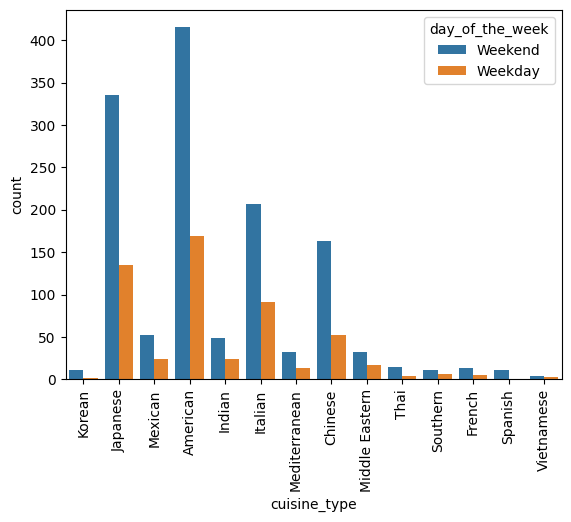

In [ ]:
sns.countplot(data,x='cuisine_type')
plt.xticks(rotation=90)
plt.show()
sns.countplot(data,x='cuisine_type',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

Observations:
1. As per histogram, kde lines shows that it is asymmetric type of histogram. Approximately, 450 orders range between 11 dollars and 13.5 dollars.
According to boxplot, the median of cost of the orders is around 14 dollars, 25% of order cost less than 12 dollars and 75% of orders cost less than 22 dollars.

2. Customers place more orders on weekend as compared to weekday. 1300 orders are placed by customers on weekend and 550 orders on weekday.

3. Approximately 710 customers has not given rating for the orders. 580 customers has given 5 rating for the orders, 190 has given 3 rating and 390 customers has given 4 rating for the orders.

4. Approximately 250 orders take 20-21 minutes for preparing the food. 130 orders take 21-23 minutes. 240 orders take 32-35 minutes for food prepartion. Howvere, the minimum food preparation time is 20 minutes, 25% of take 23 minutes for food preparation, 50% of orders take 27 minutes, 31 minutes are taken by 75% of the orders and the maximum time to prepare food take 35 minutes.

5. 280 orders take 28-29 minutes to deliver the food followed by 270 orders who take 24-25.5 minutes and 35 orders take 31-32 minutes. Also, the minimum time to deliver food is 15 minutes, maximum time is 33 minutes. Median is 25 minutes. 25% of orders take 20 minutes and 28 minutes are taken by 75% of the orders.

6. Approximately, 590 orders are of American cuisine type followed by 480 orders of Japnese cuisine. It means more people like American cuisine and Vietnamese cuisine are liked by few.
Moreover, American cuisine are liked more on weekend as compared to weekday. Therefore, weekend has more sales of American cuisine as compared to weekday.  



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code here
data['restaurant_name'].value_counts().head(5)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
The top most restaurant receiving maximum of 219 order is 'Shake Shack' followed by 'The Meatball Shop with 132 orders. The least restaurant in terms of receiving order from the list of top 5 restaurants is 'Parm' with 68 orders.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
data.groupby(['cuisine_type'])['day_of_the_week'].value_counts()

cuisine_type    day_of_the_week
American        Weekend            415
                Weekday            169
Chinese         Weekend            163
                Weekday             52
French          Weekend             13
                Weekday              5
Indian          Weekend             49
                Weekday             24
Italian         Weekend            207
                Weekday             91
Japanese        Weekend            335
                Weekday            135
Korean          Weekend             11
                Weekday              2
Mediterranean   Weekend             32
                Weekday             14
Mexican         Weekend             53
                Weekday             24
Middle Eastern  Weekend             32
                Weekday             17
Southern        Weekend             11
                Weekday              6
Spanish         Weekend             11
                Weekday              1
Thai            Weekend         

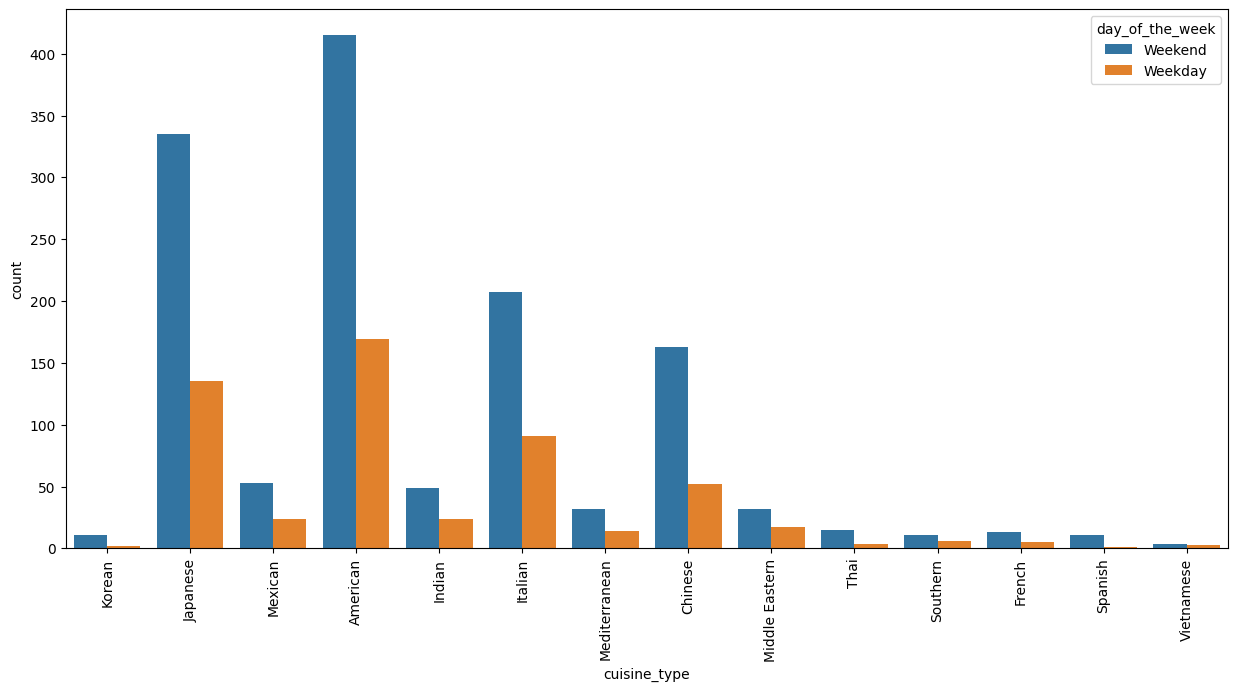

In [ ]:
plt.figure(figsize=(15,7))
sns.countplot(data,x='cuisine_type',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

#### Observations:
The most popular cuisine on weekend is American with value count of 415. This is confirmed by using groupby and also plotting histogram.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
data['Order Cost greater than 20']=data['cost_of_the_order']>20
data['Order Cost greater than 20'].value_counts(normalize=True)

Order Cost greater than 20
False   0.71
True    0.29
Name: proportion, dtype: float64

#### Observations:
29% of orders cost greater than 20 dollars as comapared to 71% of orders which cost less than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
data['delivery_time'].mean()

24.161749209694417

#### Observations:
The average or mean delivery time to deliver order is 24 minutes and 16 seconds.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
data['customer_id'].value_counts().head(3)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

#### Observations:
The company will give 20% discount vouchers to the top 3 frequent customers. First customer with customer id 52832 who has placed 13 orders, second customer with customer id 47440 having 10 orders placed and third customer with customer id 83287 with 9 orders will receice 20% discount vouchers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<ipython-input-71-278cca077ff5>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data,x='day_of_the_week',y='delivery_time',ci=False)


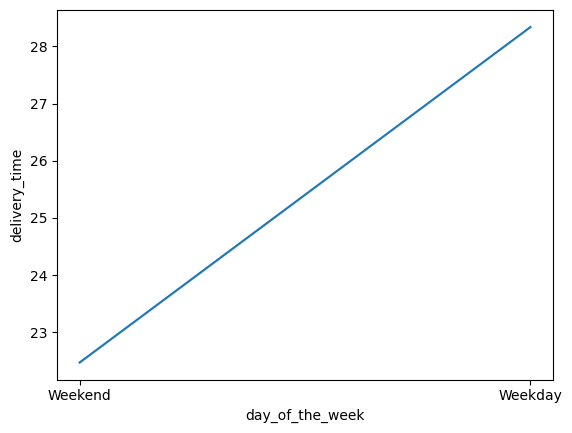

In [ ]:
# Write the code here
sns.lineplot(data,x='day_of_the_week',y='delivery_time',ci=False)
plt.show()


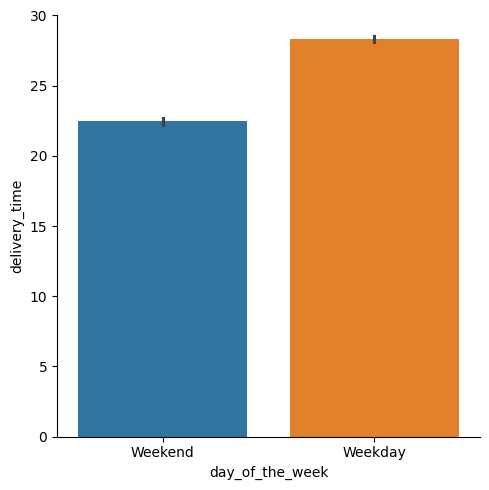

In [ ]:
sns.catplot(data,x='day_of_the_week', y='delivery_time', kind='bar', hue='day_of_the_week')
plt.show()


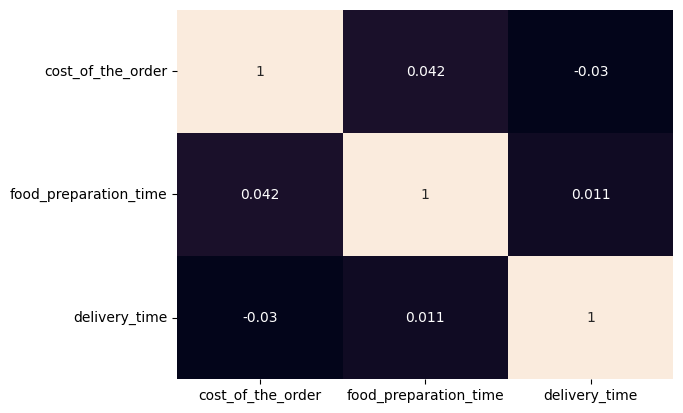

In [ ]:
var=['cost_of_the_order','food_preparation_time','delivery_time']
sns.heatmap(data[var].corr(),annot=True,cbar=False)
plt.show()

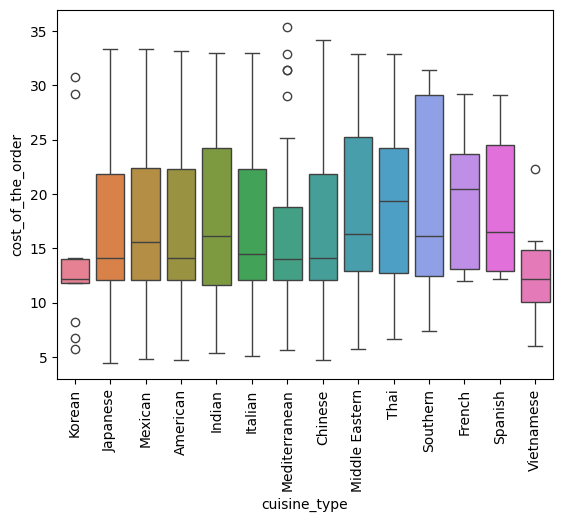

In [ ]:
sns.boxplot(data,y='cost_of_the_order',x='cuisine_type',hue='cuisine_type')
plt.xticks(rotation=90)
plt.show()

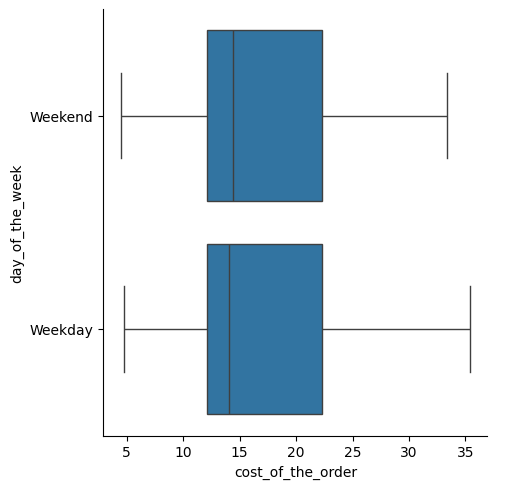

In [ ]:
sns.catplot(data,x='cost_of_the_order',y='day_of_the_week',kind='box')
plt.show()

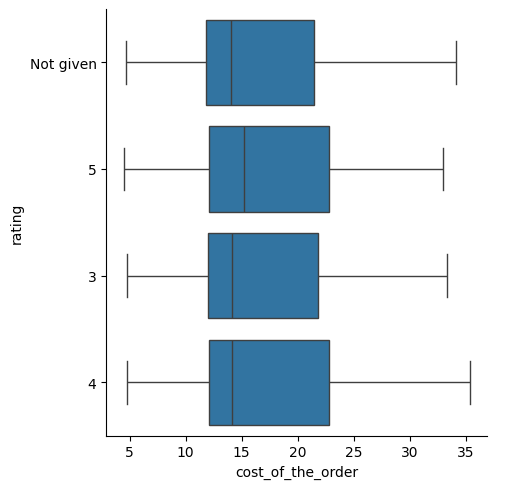

In [ ]:
sns.catplot(data,x='cost_of_the_order',y='rating',kind='box')
plt.show()

Observations:
1. The line plot shows that there is positive relationship between day of the week and delivery time. On weekend the delivery time is less as compared to weekday, weekday takes more than delivery time. Weekend takes maximum of 23 minutes to deliver the food while weekday takes maximum of 28 minutes to deliver the food.

2. There is no relationship between cost of the order, food delivery time and delivery time with each other. No further analysis is required.

3. There are outliers with mediterranean, korean and vietnamese cuisine types. The maximum cost of order for vietnamese is 15 dollars but there are outliers also. The minimum and maximum cost of order for Japanese, Mexican, American, Indian, Italian are approximately same. Also, the median which is 50% for french cuisine with respect to cost of the order is the highest.

4. The minimum, median, 25 percentile, 75 percentile are same with respect to cost of order and day of the week except for the maximum cost of order. On weekend, the maximum cost of order is 33 dollars and maximum cost of order for weekday is 35 minutes.

5. There is not much impact on rating with respect to cost of the order. Approximately rating is same for every cost of order.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
df=data[data['rating']!='Not given'].reset_index()
df

,index,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Order Cost greater than 20
0,2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,False
1,3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,True
2,4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,False
3,5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24,True
4,7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30,False
...,...,...,...,...,...,...,...,...,...,...,...
1157,1889,1478190,94152,RedFarm Broadway,Chinese,8.68,Weekday,3,33,30,False
1158,1890,1477316,164776,TAO,Japanese,15.67,Weekend,5,20,22,False
1159,1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17,True
1160,1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19,False


In [ ]:
df['rating']=df['rating'].astype('int')

In [ ]:
Restaurant_Rating_count=df.groupby(['restaurant_name']).agg({'rating':'count'}).rename(columns={'rating':'rating_count'}).sort_values(by='rating_count',ascending=False)
Restaurant_Rating_count

,rating_count
restaurant_name,
Shake Shack,133
The Meatball Shop,84
Blue Ribbon Sushi,73
Blue Ribbon Fried Chicken,64
RedFarm Broadway,41
...,...
Frank Restaurant,1
Socarrat Paella Bar,1
El Parador Cafe,1


In [ ]:
Restautant_number=Restaurant_Rating_count[Restaurant_Rating_count['rating_count']>50].shape[0]
Restautant_number

4

In [ ]:
Restaurant_Rating_Mean=df.groupby(['restaurant_name']).agg({'rating':'mean'}).rename(columns={'rating':'rating_mean'}).sort_values(by='rating_mean',ascending=False)
Restaurant_Rating_Mean

,rating_mean
restaurant_name,
'wichcraft,5.00
Ravagh Persian Grill,5.00
Chola Eclectic Indian Cuisine,5.00
Chote Nawab,5.00
Junoon,5.00
...,...
Woorijip,3.00
Byblos Restaurant,3.00
Pepe Giallo,3.00


In [ ]:
pd.concat([Restaurant_Rating_count,Restaurant_Rating_Mean],axis=1).head(Restautant_number)

,rating_count,rating_mean
restaurant_name,,
Shake Shack,133,4.28
The Meatball Shop,84,4.51
Blue Ribbon Sushi,73,4.22
Blue Ribbon Fried Chicken,64,4.33


#### Observations:
The food aggregator company FoodHub will give promotional offers to 'Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi', 'Blue Ribbon Fried Chicken' as all of these four restauarnts has rating count greater tahn 50 and mean rating greater than 4, whihc is the condition set by company for receiving promotional offer.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
Order_Cost=data['cost_of_the_order']
Order_Cost

0      30.75
1      12.08
2      12.23
3      29.20
4      11.59
        ... 
1893   22.31
1894   12.18
1895   25.22
1896   12.18
1897   19.45
Name: cost_of_the_order, Length: 1898, dtype: float64

In [ ]:
a=0
b=0
for i in range(len(Order_Cost)):

  if Order_Cost[i]>20:
      a=a+(Order_Cost[i]*0.25)
  elif Order_Cost[i]>5 and Order_Cost[i]<=20:
      b=b+(Order_Cost[i]*0.15)
print("Revenue for Cost_of_the_order > 20 is ", a,'dollars', sep='')
print("Revenue for Cost_of_the_order > 5 and <=20 is ",b,'dollars', sep='')
print('Net Revenue generated by company is ', a+b, 'dollars', sep='')

Revenue for Cost_of_the_order > 20 is 3688.7275000000027dollars
Revenue for Cost_of_the_order > 5 and <=20 is 2477.5755000000036dollars
Net Revenue generated by company is 6166.303000000006dollars


#### Observations:
The company revenue from cost of orders greater than 20 dollars is 3688.72 dollars by charging 25% on the order and company revenue from cost of orders greater than 5 dollars & less than 20 dollars is 2477.57 dollars by charging 15% on cost of orders. Therefore net revenue generated by company is 6166.30 dollars.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
data['total_time']=data['food_preparation_time']+data['delivery_time']
data

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Order Cost greater than 20,total_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,True,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,False,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,False,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,True,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,False,49
...,...,...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17,True,48
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19,False,50
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24,True,55
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31,False,54


In [ ]:
data['Total_time_greater_60']=data['total_time']>60
data['Total_time_greater_60'].value_counts(normalize=True)

Total_time_greater_60
False   0.89
True    0.11
Name: proportion, dtype: float64

#### Observations:
11% of orders take more than 60 minutes to get delivered from the time the order is placed.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
data.groupby(['day_of_the_week'])['delivery_time'].mean()

day_of_the_week
Weekday   28.34
Weekend   22.47
Name: delivery_time, dtype: float64

#### Observations:
The mean delivery time to deliver orders during weekday is 28 minutes and 34 seconds while  mean delivery time to deliver orders during weekend is 22 minutes and 47 seconds.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
1. Datset has 1898 rows means 1898 unique order id and some repetitive customers id who has placed orders again and again with company.
2. minimum time for food preparation is 20 minutes, 25% of take 23 minutes for food preparation, 50% of orders take 27 minutes, 31 minutes are taken by 75% of the orders and maximum time
 is 35 minutes, average time to prepare food is 27.37 minutes. Approximately 250 orders take 20-21 minutes for preparing the food. 130 orders take 21-23 minutes. It means out of 1898
orders, 380 orders take 20-23 minutes for preparing food. 240 orders take 32-35 minutes for food prepartion.
3. The minimum time to deliver food is 15 minutes,mean delivery time is 24.16 minutes, 25% of orders for delivery takes 20 minutes and 50% of orders take 25 minutes,
28 minutes are taken by 75% of the orders while maximum time for delivery is 33 minutes. On weekend the delivery time is less as compared to weekday, weekday takes
more than delivery time. Weekend takes maximum of 23 minutes to deliver the food while weekday takes maximum of 28 minutes to deliver the food.
Mean delivery time to deliver orders during weekday is 28.34 minutes while mean delivery time to deliver orders during weekend is 22.47 minutes.
4. average cost of order is 16.50 dollars and median is 14.14 dollars, 25% of order cost less than 12 dollars and 75% of orders cost less than 22 dollars.
 The minimum cost of order is 4.47 dollars and maximum cost of order is 35.41 dollars. 450 orders range between 11 dollars and 13.5 dollars.
 The minimum and maximum cost of order for Japanese, Mexican, American, Indian, Italian are approximately same. The minimum, median, 25 percentile, 75 percentile are same with
respect to cost of order and day of the week except for the maximum cost of order. On weekend, the maximum cost of order is 33 dollars and maximum cost of order for weekday is 35 minutes.
5.Out of total 1898, 736 orders placed by customers are not rated by them. 580 customers has given 5 rating for the orders, 190 has given 3 rating and 390 customers has given 4 rating
for the orders. There is not much impact on rating with respect to cost of the order. Approximately rating is same for every cost of order.
6. The top most restaurant receiving maximum of 219 order is 'Shake Shack' followed by 'The Meatball Shop with 132 orders. Out of total 178 restaurants, 50 restaurants have received 1 order.
7. More people like American cuisine and Vietnamese cuisine are liked by few. Moreover, American cuisine are liked more on weekend as compared to weekday. Therefore,
weekend has more sales of American cuisine as compared to weekday.
8.Customers place more orders on weekend as compared to weekday. Approximately, 1300 orders are placed by customers on weekend and 550 orders on weekday.
9. There is no relationship between cost of the order, food delivery time and delivery time with each other.

### Recommendations:

1. Company can focus more on weekend as compared to weekday as more orders are placed on weekend. Also delivery time on weekend is less as compared to weekday.
2. Maximum cost of order on weekend is 33 dollars as compared to weekday as 35 dollars. It means maximum cost of order on weekend is less.
From these two above points, if company hires more drivers for weekend, it would generate more profits for the company.
3. Company can focus more on American cuisines as most people like American cuisine and Vietnamese cuisine are least liked by them. Moreover, on weekend also, people more like American cuisine.
From this point, company can tie up more with restaurants having American cuisines in order for greater revenue as compared to present revenue.
4. The restaurants with more than 50 orders are the ones from company can expect to generate more profits. The list of the restaurants having orders greater than 50 are:-
(i) Shake Shack -219 orders.
(ii) The meatball shop- 132 orders.
(iii) Blue Ribbon Sushi- 119 orders.
(iv) Blue Ribbon fried Chicken- 96 orders.
(v) Parm -69 orders.
(vi) Red farm Broadway- 59 orders.
(vii) Red Farm Hudson- 55 Orders.
Company can focus more on these 7 restauarnts in order to generate more revenue.

5. Therefore, if company focuses on weekends with American cuisine and more focused on these 7 restaurants mentioned above can generate more profits.



---